### Bagging算法
- Bagging的思想比较简单，从原始样本集中使用Bootstraping的方法有放回的抽取n个训练样本（可能出现有些样本被多次抽到，而有些样本可能一次都没有被抽中），共进行k轮抽取，得到k个训练集，就是建立k个基学习器，最终结果由大家投票/平均值决定.
- Bagging的基学习器是可以指定的
- Bagging会进行样本随机抽样
- Bagging会进行特征随机抽样(经典定义上是不会随机特征的, 但sklearn实现上实现了随机特征, 是在生成树之前,选定好特征个数)
- RandomForest是Bagging算法的一种经典算法,(在树节点分裂的时候,进行随机特征选择),它的学习器是固定的是决策树.
### Boosting算法

In [73]:
import matplotlib.cm
## 有放回抽样和无放回抽样的对比
import numpy as np

X = np.arange(1, 100, 1)
test = np.array([])
for i in range(10):
    ## 无放回抽样
    print(np.random.choice(len(X), 20, replace=False))
print("------------------------------------------")
for i in range(10):
    ## 有放回抽样
    print(np.random.choice(len(X), 20, replace=True))

# 在一次choice时,有放回抽样,可能存在相同的样本, 无放回抽样,则不可能存在相同的样本

[15  5 95 67 66 65 53 89 90  2 16 59 11 80 24 55 87 78 79 17]
[53 32 85 63 61 20  3 27 82 44 64 65 52  1 45 49 51 84 67 95]
[ 5 36 56 85 63 27 15 12 53 31 55 57 88 86  2 16 10 61 72 14]
[75 92 81 34 65  5 19 53 60 96 39  9 29 85 12  0 86 21 11 20]
[39 61 51 19 17 35 81 22 79 56 49  3 90 47 11 87  4 30 88 42]
[48 43 79 22  5 27 54 17 56  8 53 67 15 21 86 58 71 78 80 87]
[34 17 91 76 75 94  7 77  8 23 57 14  9 79  3 58 72 25 30 42]
[81 70 40 35 58 18 52 64 77 33 20 29  7 55 25 73 10 92 97  3]
[69 79  5 15 18 60 31  9 46 84 49 67 28 14 90 10 29 44 97 58]
[84 91 97 73 65 23 32 93 98  6 70 87 72 85 14 19 10 49 57 11]
------------------------------------------
[45 11 94 60 98 75 59 93 88 13 45 13  5 84 89 89 15 59 32 24]
[46  3 89 61 52 37 26 85 10 87 20 74 83 74 39 23  0 55 69 86]
[27 27 78 43 72 98 35 19 59 77 32 42 39 20 65 37 39 70 54 81]
[18 62 62 19 63 87 10 80 44 61  7 18 79 70 27 12  1 69 35 13]
[53 28 69 49 22 53 96 78 83 82 80 83 70 61 12 15 30 10 73 31]
[91 50 60 26 36 11  8 63 46

In [74]:
### 随机数种子,当你定义一个种子后
### 每次运行整个代码,他的结果是一样的, 但定义好种子后,每次执行随机操作,结果是不一样的
rng = np.random.RandomState(42)
for i in range(3):
    print(rng.choice(len(X), 20, replace=True))

print("*"*50)
for i in range(3):
    rng = np.random.RandomState(42)
    print(rng.choice(len(X), 20, replace=True))

[51 92 14 71 60 20 82 86 74 74 87 23  2 21 52  1 87 29 37  1]
[63 59 20 32 75 57 21 88 48 90 58 41 91 59 79 14 61 61 46 61]
[50 54 63  2 50  6 20 72 38 17  3 88 59 13  8 89 52  1 83 91]
**************************************************
[51 92 14 71 60 20 82 86 74 74 87 23  2 21 52  1 87 29 37  1]
[51 92 14 71 60 20 82 86 74 74 87 23  2 21 52  1 87 29 37  1]
[51 92 14 71 60 20 82 86 74 74 87 23  2 21 52  1 87 29 37  1]


### 种子就像一本随机数生成食谱的起始页码。一旦你从这页开始读，每读一行，你都会翻到下一页。所以，虽然你每次运行程序都会从相同的起始页（种子）开始，但每次循环迭代都会从食谱的“当前页”继续往下读，所以每次读到的内容（生成的随机数）都不同。


#### Bagging算法实现

In [75]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import mode

class CustomBaggingClassifier:
    def __init__(self, n_estimators=10, max_samples=1.0, max_features=1.0, bootstrap=True, random_state=None):
        """
        Custom Bagging Classifier using NumPy.

        Parameters:
        - n_estimators: Number of base estimators (decision trees).
        - max_samples: Proportion or number of samples to draw for each base estimator.
        - max_features: Proportion or number of features to draw for each base estimator.
        - bootstrap: Whether to use bootstrap sampling (True) or not (False).
        - random_state: Random seed for reproducibility.
        """
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.estimators_ = []
        self.estimator_features_ = []

    def fit(self, X, y):
        """
        Fit the bagging classifier.

        Parameters:
        - X: Training data (numpy array, shape [n_samples, n_features]).
        - y: Target labels (numpy array, shape [n_samples]).
        """
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # Convert max_samples and max_features to integers if they are proportions
        max_samples = int(self.max_samples * n_samples) if isinstance(self.max_samples, float) else self.max_samples
        max_features = int(self.max_features * n_features) if isinstance(self.max_features, float) else self.max_features

        self.estimators_ = []
        self.estimator_features_ = []

        for _ in range(self.n_estimators):
            # Create decision tree
            tree = DecisionTreeClassifier(random_state=np.random.randint(0, 10000))

            # Bootstrap sampling
            if self.bootstrap:
                sample_indices = np.random.choice(n_samples, size=max_samples, replace=True)
            else:
                sample_indices = np.random.choice(n_samples, size=max_samples, replace=False)

            # Random feature selection
            feature_indices = np.random.choice(n_features, size=max_features, replace=False)

            # Subset data
            X_subset = X[sample_indices][:, feature_indices]
            y_subset = y[sample_indices]

            # Train decision tree
            tree.fit(X_subset, y_subset)

            # Store estimator and selected features
            self.estimators_.append(tree)
            self.estimator_features_.append(feature_indices)

        return self

    def predict(self, X):
        """
        Predict class labels for samples in X.

        Parameters:
        - X: Input data (numpy array, shape [n_samples, n_features]).

        Returns:
        - Predicted class labels (numpy array, shape [n_samples]).
        """
        n_samples = X.shape[0]
        predictions = np.zeros((n_samples, self.n_estimators), dtype=int)

        # Collect predictions from each tree
        for i, (tree, feature_indices) in enumerate(zip(self.estimators_, self.estimator_features_)):
            X_subset = X[:, feature_indices]
            predictions[:, i] = tree.predict(X_subset)

        # Majority voting
        y_pred, _ = mode(predictions, axis=1)
        return np.array(y_pred.flatten())

# Example usage
if __name__ == "__main__":
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score

    from sklearn.datasets import load_iris
    X, y = load_iris(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train custom bagging classifier
    bagging = CustomBaggingClassifier(
        n_estimators=10,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=42
    )
    bagging.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = bagging.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("结果:", y_pred)

Accuracy: 1.0000
结果: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


### 随机森林算法

In [76]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import mode

class CustomRandomForestClassifier:
    def __init__(self, n_estimators=10, max_samples=1.0, max_features="sqrt", bootstrap=True, random_state=None):
        """
        Custom Random Forest Classifier using NumPy and sklearn's DecisionTreeClassifier.

        Parameters:
        - n_estimators: Number of decision trees.
        - max_samples: Proportion or number of samples to draw for each tree.
        - max_features: Proportion, number, or method ("sqrt", "log2") for features at each split.
        - bootstrap: Whether to use bootstrap sampling (True) or not (False).
        - random_state: Random seed for reproducibility.
        """
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state
        self.estimators_ = []

    def fit(self, X, y):
        """
        Fit the random forest classifier.

        Parameters:
        - X: Training data (numpy array, shape [n_samples, n_features]).
        - y: Target labels (numpy array, shape [n_samples]).
        """
        np.random.seed(self.random_state)
        n_samples = X.shape[0]

        # Convert max_samples to integer if it's a proportion
        # 随机样本
        max_samples = int(self.max_samples * n_samples) if isinstance(self.max_samples, float) else self.max_samples

        self.estimators_ = []

        for _ in range(self.n_estimators):
            # Create decision tree with random feature selection at each split
            tree = DecisionTreeClassifier(
                # 这里配置最大特征数,由底层的决策树参数决定分裂时的特征个数
                max_features=self.max_features,  # Random feature selection at each split
                random_state=np.random.randint(0, 10000)
            )

            # Bootstrap sampling
            if self.bootstrap:
                sample_indices = np.random.choice(n_samples, size=max_samples, replace=True)
            else:
                sample_indices = np.random.choice(n_samples, size=max_samples, replace=False)

            # Subset data
            X_subset = X[sample_indices]
            y_subset = y[sample_indices]

            # Train decision tree
            tree.fit(X_subset, y_subset)

            # Store estimator
            self.estimators_.append(tree)

        return self

    def predict(self, X):
        """
        Predict class labels for samples in X.

        Parameters:
        - X: Input data (numpy array, shape [n_samples, n_features]).

        Returns:
        - Predicted class labels (numpy array, shape [n_samples]).
        """
        n_samples = X.shape[0]
        predictions = np.zeros((n_samples, self.n_estimators), dtype=int)

        # Collect predictions from each tree
        for i, tree in enumerate(self.estimators_):
            predictions[:, i] = tree.predict(X)

        # Majority voting
        y_pred, _ = mode(predictions, axis=1)
        return y_pred.flatten()

# Example usage
if __name__ == "__main__":
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score
    from sklearn.datasets import load_iris

    # Generate sample data
    X, y = load_iris(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train custom random forest classifier
    rf = CustomRandomForestClassifier(
        n_estimators=10,
        max_samples=0.8,
        max_features="sqrt",  # Use sqrt(n_features) at each split
        bootstrap=True,
        random_state=42
    )
    rf.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [77]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X, y)
### 集成算法中,可以知道哪些特征比较重要!!!
rfc.feature_importances_

array([0.13344641, 0.01857171, 0.41134994, 0.43663194])

### Boosting算法
---

## 什么是 Boosting？

**Boosting** 是一种强大的机器学习集成学习技术，它的核心思想是**将多个弱学习器（weak learners）组合起来，形成一个强大的预测模型**。Boosting 的独特之处在于，它通过**迭代地训练学习器**，并且在每一次迭代中，**更加关注之前被错误分类的样本**。你可以把它想象成一个团队合作解决问题：

* **第一次尝试：** 团队成员 A 尝试解决问题，但犯了一些错误。
* **第二次尝试：** 团队成员 B 在 A 的基础上学习，并特别关注 A 犯错的地方，尝试纠正这些错误。
* **后续尝试：** 团队成员 C、D 等依次加入，每个人都从前一个人的错误中学习，并尽力弥补。

最终，所有团队成员的努力被整合起来，形成一个比任何个体都更强大的解决方案。

---

## Boosting 的核心原理

Boosting 的原理可以概括为以下几个关键点：

1.  **序列化训练 (Sequential Training):** Boosting 算法是**顺序的**。每个新的弱学习器都会在前一个学习器的基础上进行训练，而不是像 Bagging（例如随机森林）那样并行训练。

2.  **关注错误样本 (Focus on Misclassified Samples):** 这是 Boosting 的精髓。在每一次迭代中，算法会给那些被前一个学习器**错误分类的样本赋予更高的权重**。这样，下一个弱学习器在训练时就会更加重视这些“难题”，努力将它们正确分类。

3.  **弱学习器加权组合 (Weighted Combination of Weak Learners):** 最终的强预测模型是所有弱学习器的**加权和**。每个弱学习器被赋予的权重取决于它的性能，表现越好的学习器（错误率越低）会获得更高的权重。

4.  **逐步优化 (Incremental Improvement):** Boosting 是一种贪婪的算法，它在每一步都试图优化整体模型的性能，通过不断地减少误差来逐步提升模型的准确性。

- 典型算法代表由:AdaBoost, Xgboost

# AdaBoost算法实现

In [78]:

from sklearn.tree import DecisionTreeClassifier
import numpy as np

class CustomAdaBoostClassifier:
    def __init__(self, n_estimators=50, learning_rate=1.0, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.estimators_ = []
        self.estimator_weights_ = [] ## 评估器权重

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        ## 重设预测值 确保y值「-1, 1」AdaBoost的sign要求
        y = np.where(y == 0, -1, 1)
        ## 初始化权重值
        sample_weights = 1/n_samples * np.ones(n_samples)
        for _ in range(self.n_estimators):
            ## 决策树桩--最简单的弱学习器,不怕弱,因为多,且越来越强
            stump = DecisionTreeClassifier(max_depth=1, random_state=np.random.randint(0, 10000))
            stump.fit(X, y, sample_weight=sample_weights)
            y_hat = stump.predict(X)
            err_mask= y != y_hat
            ## 计算错误率
            err = np.sum(sample_weights[err_mask]) / np.sum(sample_weights)
            ## 计算评估器(决策树桩)的权重
            if 0 < err < 1:
                alpha = self.learning_rate * 0.5 * np.log((1 - err) / (err + 1e-10))
            else:
                ## alpha=0,代表跳过该学习器,权重不会更新
                alpha = 0
            ## 更新样本的权重
            sample_weights = sample_weights * np.exp(-alpha * y * y_hat)
            sample_weights /= np.sum(sample_weights) + 1e-10

            self.estimators_.append(stump)
            self.estimator_weights_.append(alpha)

    def predict(self, X):
        y_preds = np.array([estimator.predict(X) for estimator in self.estimators_])
        return np.where(np.sum(y_preds.T * np.array(self.estimator_weights_), axis=1) >= 0, 1, 0)

if __name__ == '__main__':
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score
    from sklearn.datasets import load_breast_cancer

    # Generate sample data
    X, y = load_breast_cancer(return_X_y=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and train custom random forest classifier
    rf = CustomAdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
    rf.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"CustomAda Accuracy: {accuracy:.4f}")

    from sklearn.ensemble import AdaBoostClassifier
    abc = AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    abc.fit(X_train, y_train)
    y_pred = abc.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Sklearn Ada Accuracy: {accuracy:.4f}")

CustomAda Accuracy: 0.9591
Sklearn Ada Accuracy: 0.9591


### 这里要注意的点:
* 弱学习器权重 (α)： 取决于当前弱学习器的整体表现。表现越好（错误率越低），权重越大。
* 样本权重： 取决于当前弱学习器对单个样本的分类情况。被正确分类的样本权重减小；被错误分类的样本权重增大。




# GDBT算法

In [79]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

class GBDTRegressorWithSklearnTree:
    """
    一个使用 Scikit-learn DecisionTreeRegressor 作为弱学习器的 GBDT 回归器。
    """
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth # 控制弱学习器（树）的复杂度
        self.initial_prediction = None # F0(x)
        self.trees = [] # 存储所有弱学习器

    def fit(self, X, y):
        n_samples = X.shape[0]

        # 1. 初始化 F0(x) 为目标变量的平均值
        self.initial_prediction = np.mean(y)
        # current_predictions 存储当前集成模型的累积预测
        current_predictions = np.full(n_samples, self.initial_prediction)

        # 2. 迭代训练弱学习器
        for i in range(self.n_estimators):
            # 计算当前模型的残差 (对于MSE损失，这正是负梯度)
            residuals = y - current_predictions

            # 训练一个新的弱学习器（决策树）来拟合这些残差
            # max_depth 参数控制了每个弱学习器的复杂度，通常设置为较小的值（如1-5）
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=i) # 确保每次迭代的随机性可控
            tree.fit(X, residuals)
            self.trees.append(tree)

            # 获取新树的预测
            tree_predictions = tree.predict(X)

            # 更新当前模型的预测： F_m(x) = F_{m-1}(x) + nu * h_m(x)
            current_predictions += self.learning_rate * tree_predictions

    def predict(self, X):
        # 初始预测
        predictions = np.full(X.shape[0], self.initial_prediction)

        # 累加所有弱学习器的预测
        for tree in self.trees:
            predictions += self.learning_rate * tree.predict(X)
        return predictions


GBDT 模型（使用 Scikit-learn 决策树）训练完成。


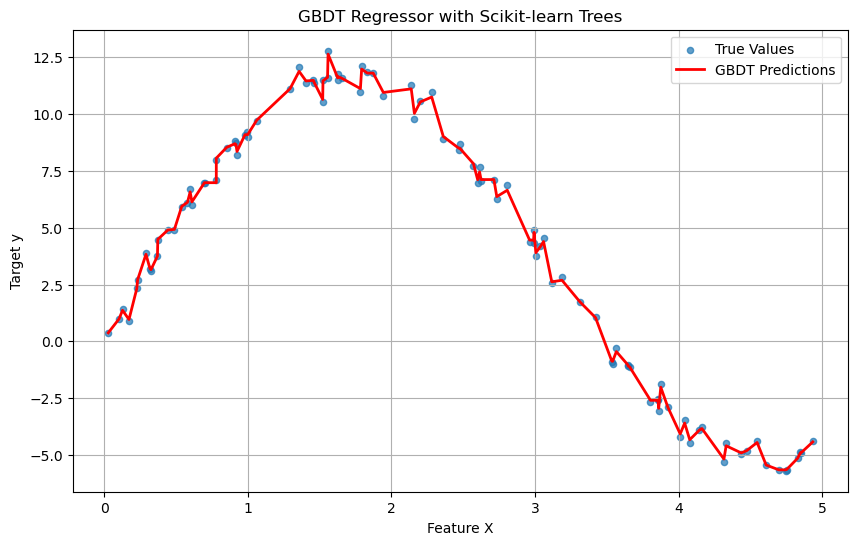


新数据点的预测:
X: 0.50, y: 5.29 Predicted y: 4.93
X: 2.50, y: 8.48 Predicted y: 8.50
X: 4.50, y: -5.28 Predicted y: -4.81


In [80]:
# 构造一些数据，模拟一个非线性关系
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0) # 100个样本，1个特征
def get_y(X):
    return np.sin(X).ravel() * 10 + X.ravel()

y = get_y(X) + np.random.normal(0, 0.5, X.shape[0]) # 加上一些噪音和线性趋势

# 实例化 GBDT 回归器，使用 Scikit-learn 的树
# 注意：max_depth通常设置为一个较小的值，使每个树成为“弱学习器”
gbdt_sklearn_tree = GBDTRegressorWithSklearnTree(n_estimators=120, learning_rate=0.15, max_depth=3)
# 训练模型
gbdt_sklearn_tree.fit(X, y)

# 进行预测
y_pred = gbdt_sklearn_tree.predict(X)

print("GBDT 模型（使用 Scikit-learn 决策树）训练完成。")

# 可视化结果
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='True Values', s=20, alpha=0.7)
plt.plot(X, y_pred, color='red', label='GBDT Predictions', linewidth=2)
plt.title('GBDT Regressor with Scikit-learn Trees')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.grid(True)
plt.show()

# 也可以在新的数据点上进行预测
X_new = np.array([[0.5], [2.5], [4.5]])
y_true = get_y(X_new)
y_new_pred = gbdt_sklearn_tree.predict(X_new)
print("\n新数据点的预测:")
for i in range(len(X_new)):
    print(f"X: {X_new[i, 0]:.2f}, y: {y_true[i]:.2f} Predicted y: {y_new_pred[i]:.2f}")



In [81]:
from sklearn.tree import DecisionTreeRegressor
class GBDTClassifier:
    def __init__(self, n_estimators=10, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.trees = []
        self.init_value = 0

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y):
        n_samples = X.shape[0]
        # 将 y 转换为 {-1, 1}
        y_trans = np.where(y == 1, 1, -1)

        # 初始化 F0(x) = 0
        F = np.zeros(n_samples)

        for m in range(self.n_estimators):
            # 计算负梯度（残差）
            residual = 2 * y_trans * self._sigmoid(-2 * y_trans * F)

            # 拟合一棵回归树
            tree = DecisionTreeRegressor(max_depth=1)
            tree.fit(X, residual)

            update = tree.predict(X)

            # 更新模型
            F += self.learning_rate * update
            self.trees.append(tree)

    def predict_logit(self, X):
        F = np.zeros(X.shape[0])
        for tree in self.trees:
            F += self.learning_rate * tree.predict(X)
        return F

    def predict_proba(self, X):
        F = self.predict_logit(X)
        probs = self._sigmoid(2 * F)
        return np.vstack([1 - probs, probs]).T

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)


In [82]:
from sklearn.datasets import load_iris
import numpy as np
X, y = load_iris(return_X_y=True)
gdbt = GBDTClassifier()
gdbt.fit(X, y)
y_pred = gdbt.predict(X)
print(y_pred.reshape(-1, 50))

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1
  1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


# 集成算法实验分析

## 软投票 硬投票
- 硬投票 采用的是最终结果的投票数,谁大选谁
- 软投票 采用的是预测的概率值,选概率最大的

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

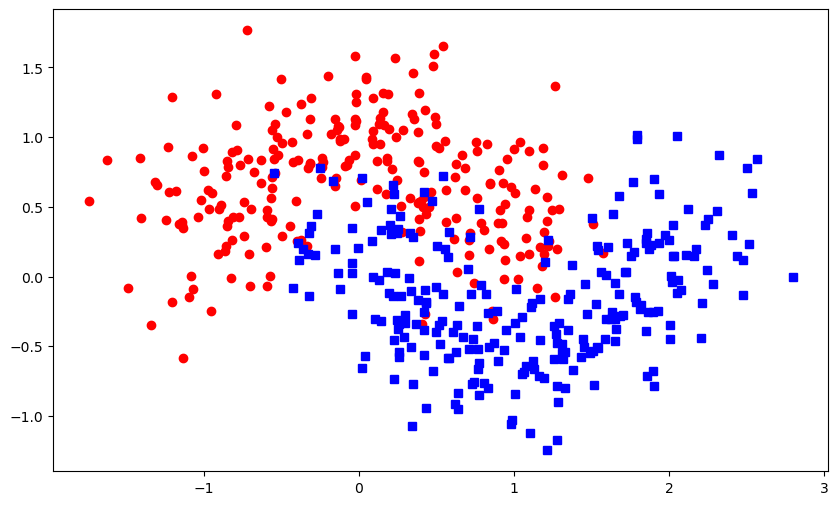

In [84]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "ro")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.show()

In [85]:
# 硬投票
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

log_clf = LogisticRegression()
rfc_clf = RandomForestClassifier()
svc_clf = SVC()
dtc_clf = DecisionTreeClassifier()
voting_clf = VotingClassifier([('lr', log_clf), ('rfc', rfc_clf), ('svc',svc_clf), ('dtc', dtc_clf)], voting='hard')

In [86]:
for clf in [log_clf, rfc_clf, svc_clf, dtc_clf, voting_clf]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"{clf.__class__.__name__}: {accuracy_score(y_test, y_pred)}")

LogisticRegression: 0.85
RandomForestClassifier: 0.89
SVC: 0.87
DecisionTreeClassifier: 0.85
VotingClassifier: 0.85


In [87]:
# 软投票 -- 分类器必须能得到概率值
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

log_clf = LogisticRegression()
rfc_clf = RandomForestClassifier()
svc_clf = SVC(kernel="rbf", probability=True)
dtc_clf = DecisionTreeClassifier()
voting_clf = VotingClassifier([('lr', log_clf), ('rfc', rfc_clf), ('svc',svc_clf), ('dtc', dtc_clf)], voting='soft')

In [88]:
for clf in [log_clf, rfc_clf, svc_clf, dtc_clf, voting_clf]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"{clf.__class__.__name__}: {accuracy_score(y_test, y_pred)}")

LogisticRegression: 0.85
RandomForestClassifier: 0.87
SVC: 0.87
DecisionTreeClassifier: 0.82
VotingClassifier: 0.88


### Bagging实验分析

In [89]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)
bag_clf.fit(X_train, y_train)
bag_pred = bag_clf.predict(X_test)
accuracy_score(y_test, bag_pred)


0.9

In [90]:
dtc_clf = DecisionTreeClassifier(random_state=42)
dtc_clf.fit(X_train, y_train)
dtc_pred = dtc_clf.predict(X_test)
accuracy_score(y_test, dtc_pred)

0.82

#### bagging和decisiontree决策边界

In [195]:
def plot_decision(clf, X, y):
    x0_min, x0_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    x1_min, x1_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx = np.linspace(x0_min, x0_max, 100)
    yy = np.linspace(x1_min, x1_max, 100)
    XX, YY = np.meshgrid(xx, yy)
    ZZ = np.c_[XX.ravel(), YY.ravel()]
    zz = clf.predict(ZZ).reshape(XX.shape)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "ro", alpha=.5)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=.8)
    contour = plt.contour(xx, yy, zz)
    plt.contourf(xx, yy, zz, alpha=0.3)
    return contour

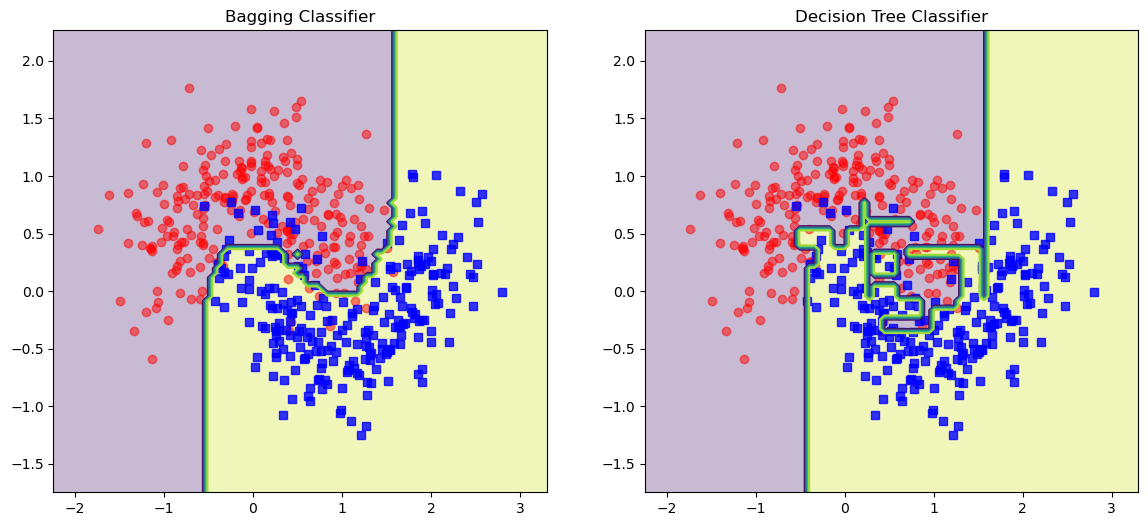

In [92]:
plt.figure(figsize=(14, 6))
plt.subplot(121)
plt.title("Bagging Classifier")
plot_decision(bag_clf, X, y)
plt.subplot(122)
plot_decision(dtc_clf, X, y)
plt.title("Decision Tree Classifier")
plt.show()

#### oob策略
- oob就是袋外严重策略, 一般模型都是可以进行交叉验证, 但Bagging模型因为样本是随机的, 不能采用正常的交叉验证,但是,天然的,Bagging采样有一些样本是没有被采样去训练,因此这些样本可以被做成验证集
- bagging算法在sklearn中带有oob参数,打开,即可求验证集评分

In [93]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=200,
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
    oob_score=True, ## 打开oob
)
bag_clf.fit(X_train, y_train)
print(f"oob验证评分:{bag_clf.oob_score_}, 测试集评分:{accuracy_score(y_test, bag_clf.predict(X_test))}")

oob验证评分:0.9225, 测试集评分:0.9


In [94]:
print(f"oob个数{bag_clf.oob_decision_function_.shape}, 样本训练个数:{X_train.shape}")

oob个数(400, 2), 样本训练个数:(400, 2)


In [95]:
## 样本预测概率
bag_clf.oob_decision_function_

array([[0.98606272, 0.01393728],
       [0.01045296, 0.98954704],
       [0.08709677, 0.91290323],
       [0.96273292, 0.03726708],
       [0.97560976, 0.02439024],
       [1.        , 0.        ],
       [0.97586207, 0.02413793],
       [0.8       , 0.2       ],
       [0.36928105, 0.63071895],
       [0.00634921, 0.99365079],
       [0.52515723, 0.47484277],
       [0.86392405, 0.13607595],
       [1.        , 0.        ],
       [0.03921569, 0.96078431],
       [0.44117647, 0.55882353],
       [0.94333333, 0.05666667],
       [0.99393939, 0.00606061],
       [1.        , 0.        ],
       [0.95065789, 0.04934211],
       [0.12460064, 0.87539936],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.78616352, 0.21383648],
       [0.9873817 , 0.0126183 ],
       [0.69395018, 0.30604982],
       [0.39041096, 0.60958904],
       [0.40133779, 0.59866221],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.00308642, 0.99691358],
       [0.

In [96]:
### 集成算法的重要特征
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y)
rfc_clf = RandomForestClassifier(random_state=42)
rfc_clf.fit(X_train, y_train)
for name, score in zip(iris.feature_names, rfc_clf.feature_importances_):
    print(f"{name}: {score:.4f}")

sepal length (cm): 0.1118
sepal width (cm): 0.0254
petal length (cm): 0.4809
petal width (cm): 0.3819


正在下载 MNIST 数据集...
MNIST 数据集下载完成！

数据集形状 (X): (70000, 784)
标签形状 (y): (70000,)

部分标签: [5 0 4 1 9 2 1 3 1 4]


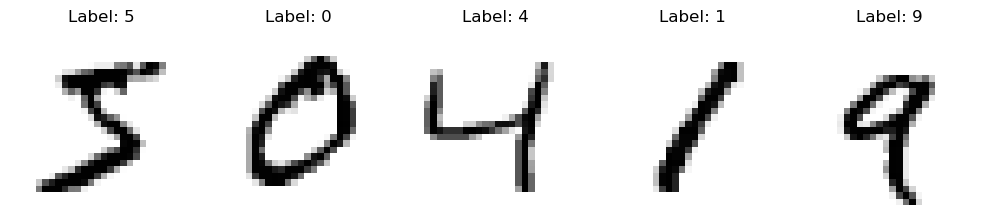

In [97]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np

# 获取 MNIST 数据集
# version='7' 是 MNIST 的一个常用版本。
# as_frame=False 表示返回 NumPy 数组而不是 Pandas DataFrame，这在大多数机器学习任务中更常用。
print("正在下载 MNIST 数据集...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("MNIST 数据集下载完成！")

# 数据集对象是一个Bunch（字典类似的对象），包含以下键：
# 'data': 包含图像像素数据的二维数组 (n_samples, n_features)
# 'target': 包含对应标签的一维数组 (n_samples,)
X, y = mnist.data, mnist.target

print(f"\n数据集形状 (X): {X.shape}") # 70000张图片，每张图片784个像素 (28*28)
print(f"标签形状 (y): {y.shape}")   # 70000个标签

# MNIST 标签通常是字符串类型，可以将其转换为整数
y = y.astype(np.uint8)

# 查看一些样本
print(f"\n部分标签: {y[:10]}")

# 示例：查看不同数字的图片
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [98]:
### sklearn数据下载路径
import os
from sklearn.datasets import get_data_home
data_home_path = get_data_home()
data_home_path, os.path.exists(data_home_path)

('/Users/hbj/scikit_learn_data', True)

In [99]:
rfc_clf = RandomForestClassifier(random_state=42)
rfc_clf.fit(mnist.data, mnist.target)

RandomForestClassifier(random_state=42)

In [100]:
rfc_clf.feature_importances_, rfc_clf.feature_importances_.shape

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 5.51836329e-07, 6.28737024e-07,
        1.51289846e-06, 2.71249325e-06, 1.82695853e-06, 2.25579254e-06,
        2.11353658e-06, 3.34985137e-06, 2.61113858e-06, 1.15745135e-06,
        2.65792911e-06, 2.05198836e-06, 0.00000000e+00, 1.87798416e-06,
        1.01740465e-06, 2.21970863e-06, 1.19879272e-06, 9.39484674e-07,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

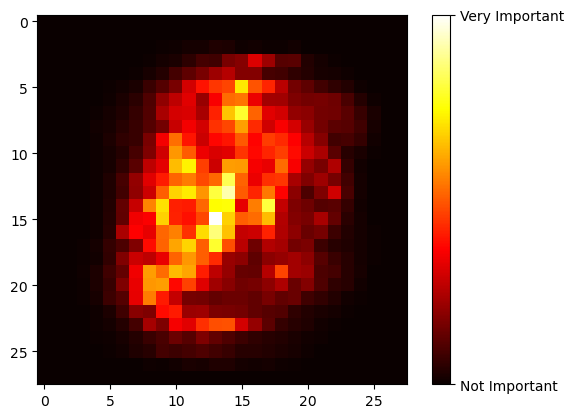

In [102]:
plt.imshow(rfc_clf.feature_importances_.reshape(28, 28), cmap="hot")
bar = plt.colorbar(ticks=[rfc_clf.feature_importances_.min(), rfc_clf.feature_importances_.max()])
bar.ax.set_yticklabels(['Not Important', 'Very Important'])
plt.show()

### AdaBoost实验分析

0.9375


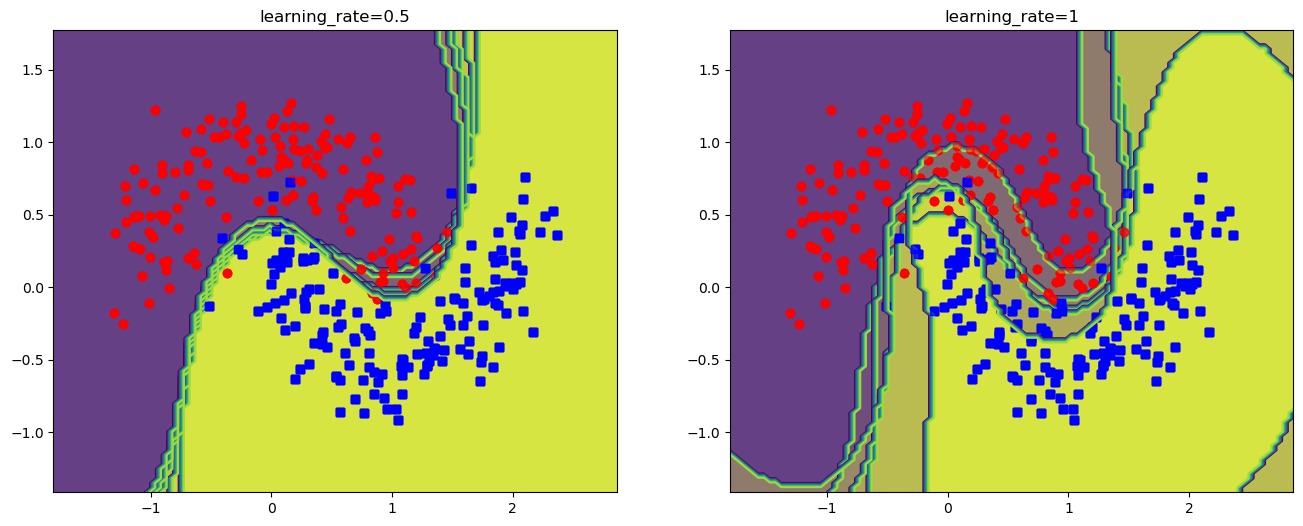

In [200]:
## 用决策树来模拟AdaBoost的过程
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from scipy.stats import mode

X, y = make_moons(n_samples=400, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_estimators = []
n_samples = len(X_train)
sample_weights = np.ones(n_samples)
n = 5

plt.figure(figsize=(16, 6))
for subplot, learning_rate in ((121, 0.5), (122, 1)):
    plt.subplot(subplot)
    for i in range(n):
        svm = SVC(random_state=42, kernel="rbf", C=0.2)
        svm.fit(X_train, y_train, sample_weight=sample_weights)
        ## 计算错误标签
        y_train_pred = svm.predict(X_train)
        err_mask = y_train_pred != y_train
        ## 更新错误标签的权重(加大)
        sample_weights[err_mask] *= (1 + learning_rate)
        ## 保存模型
        n_estimators.append(svm)
        ## 绘画每个模型的决策边界
        plot_decision(svm, X_train, y_train)
        plt.title(f"learning_rate={learning_rate}")

## 预测
y_predictions = []
for n_estimator in n_estimators:
    y_res = n_estimator.predict(X_test)
    y_predictions.append(y_res)

## 大类统计
y_p, _ = mode(y_predictions, axis=0)
accuracy = accuracy_score(y_test, y_p)
print(accuracy)

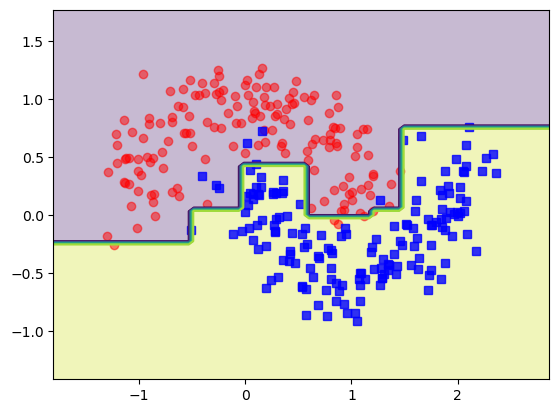

In [201]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), random_state=42, n_estimators=200, learning_rate=0.1)
adaboost_clf.fit(X_train, y_train)

plot_decision(adaboost_clf, X_train, y_train)

### GDBT实验分析